# Football Player Analytics — Expanded Representation
**Regression + Classification + Clustering**, now on a rich, role-descriptive feature set.

This notebook keeps the original **5-feature baseline** experiment unchanged and adds an **expanded**
(~30-feature) representation grouped into football concepts, with position-aware profiling, role-aware
clustering and a richer similarity space. It proves the expanded set with cross-validation and
clustering diagnostics rather than assuming it is better.

Data: FBref Big-5 league player stats merged by `scripts/build_dataset.py` (standard, shooting, passing,
possession, defense, misc). **Pressing metrics are intentionally absent** — FBref no longer publishes
player-level pressures (StatsBomb removed them in 2023), so we use other defensive actions instead.
We analyse the **2024** season (one row per player).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, silhouette_score)
SEASON, MIN_MINUTES, RANDOM_STATE = 2024, 450, 42
sns.set_theme(style="whitegrid")

## 1. Load + data-quality checks

In [2]:
raw = pd.read_csv("data/players.csv", low_memory=False)
df = raw[raw.Season == SEASON].copy()
print("2024 rows:", len(df), "| columns:", df.shape[1])

PCT_COLS = ["PassAcc", "LongPassAcc", "TakeOnPct", "TackleSuccessPct", "AerialWinPct"]
ID_COLS = ["Player", "Team", "League", "Season", "Pos", "Age", "Minutes"]
COUNT_COLS = [c for c in df.columns if c not in ID_COLS + PCT_COLS]

# data-quality checks (report, do not silently drop)
issues = {
    "duplicate player-team rows": int(df.duplicated(["Player", "Team"]).sum()),
    "negative counts": int((df[COUNT_COLS] < 0).sum().sum()),
    "pct outside 0-100": int(((df[PCT_COLS] < 0) | (df[PCT_COLS] > 100)).sum().sum()),
    "zero-minute players": int((df.Minutes <= 0).sum()),
}
print("Data-quality checks:", issues)

2024 rows: 2852 | columns: 46
Data-quality checks: {'duplicate player-team rows': 0, 'negative counts': 0, 'pct outside 0-100': 0, 'zero-minute players': 0}


## 2. Cleaning + centralised feature engineering
One function builds every per-90 rate consistently (`count / minutes * 90`); percentages are left as-is.
Rate-given-attempts percentages are NaN when the player never attempted the action (e.g. 0 take-ons) —
we fill those with 0, since the matching per-90 *volume* feature already carries "they don't do it".

In [3]:
def clean(d):
    d = d.drop_duplicates(["Player", "Team"])
    d = d[d.Pos != "GK"]
    d = d[d.Minutes >= MIN_MINUTES].copy()
    d[PCT_COLS] = d[PCT_COLS].fillna(0.0)
    d[COUNT_COLS] = d[COUNT_COLS].fillna(0.0)
    return d.reset_index(drop=True)

def add_per90(d):
    n90 = d.Minutes / 90
    for c in COUNT_COLS:
        d[c + "_p90"] = d[c] / n90
    return d

n0 = len(df)
df = add_per90(clean(df))
df["Position"] = df.Pos.str.split(",").str[0].map({"DF": "Defender", "MF": "Midfielder", "FW": "Forward"})
df = df.dropna(subset=["Position"]).reset_index(drop=True)
df["Score"] = df.Goals_p90 + df.Assists_p90
THRESHOLD = df.Score.median()
df["Label"] = (df.Score > THRESHOLD).astype(int)
print(f"after cleaning: {len(df)} players (from {n0}); High/Low balance: {df.Label.mean():.2f}")

after cleaning: 1826 players (from 2852); High/Low balance: 0.50


## 3. Feature groups (football concepts)
The metrics are organised into concept groups. These power grouped explainability, category indices and
the role-aware radar — so an "Attacking" profile is justified by *attacking metrics*, not just a cluster id.

In [4]:
GROUPS = {
  "Shooting":    ["Shots_p90", "ShotsOnTarget_p90", "xG_p90", "npxG_p90"],
  "Creation":    ["KeyPasses_p90", "xAG_p90", "PassesPenArea_p90", "AttPenTouches_p90"],
  "Passing":     ["Passes_p90", "PassAcc", "LongPassAcc", "ProgPasses_p90", "PassesFinalThird_p90"],
  "Progression": ["ProgCarries_p90", "CarriesFinalThird_p90", "CarriesPenArea_p90", "ProgReceptions_p90"],
  "Carrying":    ["Touches_p90", "Carries_p90", "TakeOns_p90", "TakeOnPct"],
  "Defending":   ["Tackles_p90", "TacklesWon_p90", "Interceptions_p90", "Blocks_p90", "Clearances_p90", "TackleSuccessPct"],
  "Aerial":      ["AerialsWon_p90", "AerialWinPct"],
}
PROFILING = [f for g in GROUPS.values() for f in g]          # ~28 style features
SIMILARITY = PROFILING                                        # similarity uses the same style space
BASELINE = ["Shots_p90", "Passes_p90", "PassAcc", "Tackles_p90", "Interceptions_p90"]
OUTCOME = ["xG_p90", "npxG_p90", "xAG_p90"]                   # outcome-correlated -> excluded from strict model
EXPANDED_A = [f for f in PROFILING if f not in OUTCOME]       # strict: no outcome-derived features
EXPANDED_B = PROFILING                                        # adds xG/npxG/xAG
print(f"profiling features: {len(PROFILING)} | baseline: {len(BASELINE)} | expanded-A: {len(EXPANDED_A)} | expanded-B: {len(EXPANDED_B)}")
assert not ({"Goals_p90", "Assists_p90", "NpGoals_p90", "Score"} & set(PROFILING))   # no raw target components

profiling features: 29 | baseline: 5 | expanded-A: 26 | expanded-B: 29


## 4. Feature redundancy (correlation)
With many metrics, multicollinearity appears. We flag highly correlated pairs (|r| > 0.85) but keep both
when they describe distinct football concepts (e.g. shots vs xG).

Highly correlated pairs (|r|>0.85):
  Passes_p90               Touches_p90              r=+0.99
  xG_p90                   npxG_p90                 r=+0.98
  Tackles_p90              TacklesWon_p90           r=+0.94
  Shots_p90                ShotsOnTarget_p90        r=+0.92
  ShotsOnTarget_p90        npxG_p90                 r=+0.89
  Touches_p90              Carries_p90              r=+0.89
  Passes_p90               Carries_p90              r=+0.88
  ShotsOnTarget_p90        xG_p90                   r=+0.88
  ProgPasses_p90           PassesFinalThird_p90     r=+0.86
  KeyPasses_p90            xAG_p90                  r=+0.86
  Shots_p90                npxG_p90                 r=+0.85
  Shots_p90                AttPenTouches_p90        r=+0.85


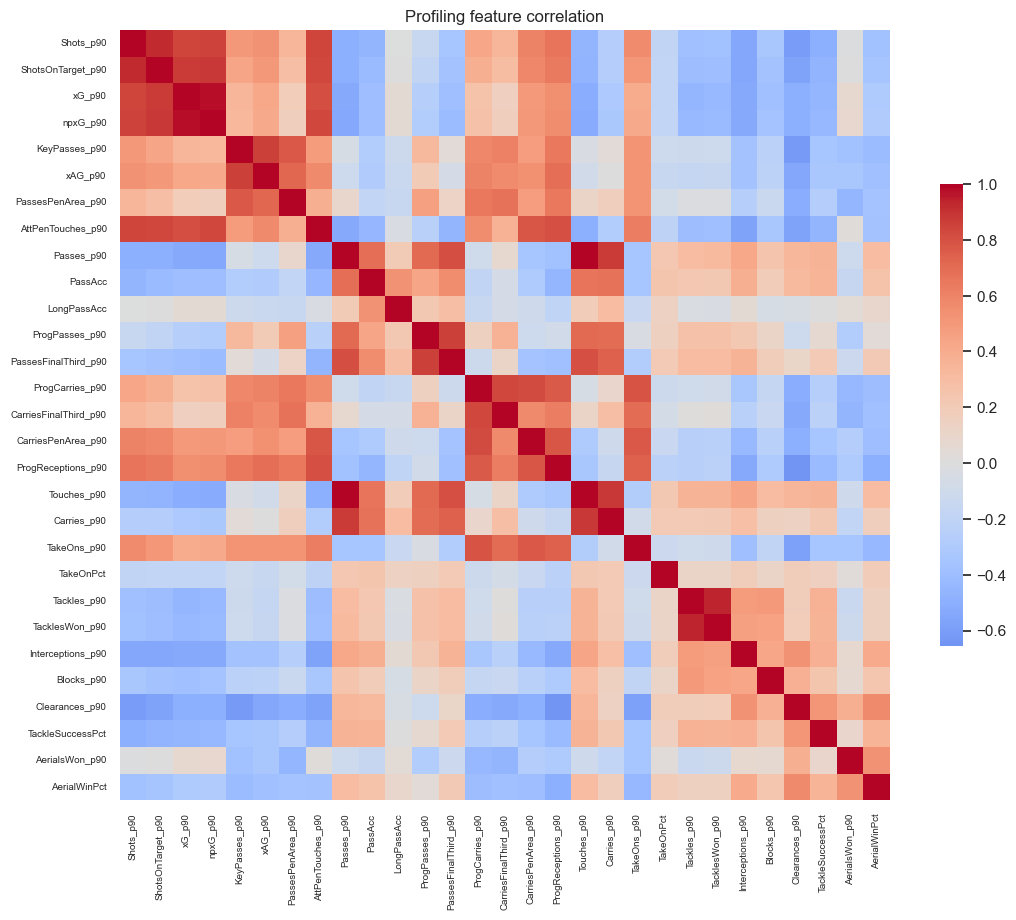

In [5]:
corr = df[PROFILING].corr()
pairs = [(PROFILING[i], PROFILING[j], corr.iloc[i, j])
         for i in range(len(PROFILING)) for j in range(i + 1, len(PROFILING)) if abs(corr.iloc[i, j]) > 0.85]
print("Highly correlated pairs (|r|>0.85):")
for a, b, r in sorted(pairs, key=lambda x: -abs(x[2])):
    print(f"  {a:24s} {b:24s} r={r:+.2f}")
plt.figure(figsize=(13, 10)); sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
    cbar_kws={"shrink": .6}, xticklabels=True, yticklabels=True)
plt.title("Profiling feature correlation"); plt.xticks(fontsize=7, rotation=90); plt.yticks(fontsize=7); plt.show()

## 5. Percentile transform + position-aware normalisation
Many count metrics are right-skewed and on very different scales, so for profiling/similarity we convert
every feature to its **percentile rank (0-100)**. This is robust to outliers and makes cross-metric
comparison meaningful (Step 32). We also compute **within-position** percentiles: 3 shots/90 is ordinary
for a forward but remarkable for a defender.

In [6]:
pct_overall = df[PROFILING].rank(pct=True) * 100                       # 0-100 overall
pct_pos = df.groupby("Position")[PROFILING].rank(pct=True) * 100       # 0-100 within position
pct_overall.columns = [c + "__pct" for c in PROFILING]
# category indices = mean percentile within each football group
CAT = {}
for g, feats in GROUPS.items():
    CAT["idx_" + g] = (df[feats].rank(pct=True) * 100).mean(axis=1)
cat_df = pd.DataFrame(CAT).round(1)
df = pd.concat([df, cat_df], axis=1)
print("Category indices (0-100), first rows:")
display(df[["Player", "Position"] + list(cat_df.columns)].head())

Category indices (0-100), first rows:


,Player,Position,idx_Shooting,idx_Creation,idx_Passing,idx_Progression,idx_Carrying,idx_Defending,idx_Aerial
0,Abdel Abqar,Defender,14.7,10.0,23.3,5.3,28.7,58.9,64.0
1,Carlos Benavídez,Midfielder,55.5,32.5,42.3,23.9,28.0,78.2,78.9
2,Antonio Blanco,Midfielder,24.7,34.6,56.6,24.4,42.7,55.1,50.3
3,Rubén Duarte,Defender,31.3,38.9,34.7,28.9,33.1,66.5,58.4
4,Andoni Gorosabel,Defender,20.9,41.1,45.8,52.9,42.1,56.9,24.5


## 6. Baseline (5) vs Expanded classification
Target: **High = score above median** (unchanged). We compare three feature sets with 5-fold CV and the
test split. **Leakage control:** goals/assists are never inputs; `Expanded-A` also excludes xG/npxG/xAG
(outcome-correlated), while `Expanded-B` adds them so the effect is explicit. We report Accuracy, F1 and
ROC-AUC — not accuracy alone.

In [7]:
y = df.Label
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
def evaluate(feats, tag):
    X = df[feats]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    rows = []
    models = {"Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
              "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
              "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                                      random_state=RANDOM_STATE, n_jobs=-1)}
    for name, m in models.items():
        acc = cross_val_score(m, Xtr, ytr, cv=skf, scoring="accuracy")
        f1 = cross_val_score(m, Xtr, ytr, cv=skf, scoring="f1")
        auc = cross_val_score(m, Xtr, ytr, cv=skf, scoring="roc_auc")
        m.fit(Xtr, ytr); p = m.predict(Xte)
        try: pa = m.predict_proba(Xte)[:, 1]
        except Exception: pa = p
        rows.append({"Representation": tag, "n_features": len(feats), "Model": name,
                     "CV acc": acc.mean(), "CV F1": f1.mean(), "CV AUC": auc.mean(),
                     "Test acc": accuracy_score(yte, p), "Test F1": f1_score(yte, p),
                     "Test AUC": roc_auc_score(yte, pa)})
    return rows

expanded_clf = pd.DataFrame(evaluate(BASELINE, "Baseline (5)") +
                            evaluate(EXPANDED_A, "Expanded-A (no xG)") +
                            evaluate(EXPANDED_B, "Expanded-B (+xG)")
                           ).set_index(["Representation", "Model"]).round(3)
expanded_clf

n_features  CV acc  CV F1  CV AUC  \
Representation     Model                                                    
Baseline (5)       Logistic Regression           5   0.796  0.783   0.879   
                   Decision Tree                 5   0.779  0.771   0.843   
                   Random Forest                 5   0.792  0.788   0.872   
Expanded-A (no xG) Logistic Regression          26   0.831  0.825   0.907   
                   Decision Tree                26   0.793  0.788   0.847   
                   Random Forest                26   0.829  0.824   0.903   
Expanded-B (+xG)   Logistic Regression          29   0.840  0.832   0.920   
                   Decision Tree                29   0.807  0.804   0.866   
                   Random Forest                29   0.834  0.831   0.914   

                                        Test acc  Test F1  Test AUC  
Representation     Model                                             
Baseline (5)       Logistic Regression     0.806    0.797     0.884  
                   Decision Tree           0.801    0.797     0.867  
                   Random Forest           0.806    0.801     0.880  
Expanded-A (no xG) Logistic Regression     0.850    0.848     0.925  
                   Decision Tree           0.806    0.800     0.867  
                   Random Forest           0.833    0.834     0.920  
Expanded-B (+xG)   Logistic Regression     0.836    0.831     0.932  
                   Decision Tree           0.836    0.835     0.909  
                   Random Forest           0.847    0.849     0.934

## 7. Baseline experiment (unchanged) — regression + 5-feature results
Kept exactly as the original project so the app's Analytics stays consistent.

In [8]:
X5 = df[BASELINE]; yreg = df.Score
Xtr, Xte, yr_tr, yr_te, yc_tr, yc_te = train_test_split(X5, yreg, y, test_size=0.2,
                                                        random_state=RANDOM_STATE, stratify=y)
reg_models = {"Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
              "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                                     random_state=RANDOM_STATE, n_jobs=-1)}
reg_rows, reg_pred = [], {}
for name, m in reg_models.items():
    m.fit(Xtr, yr_tr); p = m.predict(Xte); reg_pred[name] = p
    reg_rows.append({"Model": name, "MAE": mean_absolute_error(yr_te, p),
                     "RMSE": np.sqrt(mean_squared_error(yr_te, p)), "R2": r2_score(yr_te, p)})
reg_results = pd.DataFrame(reg_rows).set_index("Model").round(4)

clf_models = {"Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
              "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)}
clf_rows, clf_pred = [], {}
for name, m in clf_models.items():
    m.fit(Xtr, yc_tr); p = m.predict(Xte); clf_pred[name] = p
    clf_rows.append({"Model": name, "Accuracy": accuracy_score(yc_te, p), "Precision": precision_score(yc_te, p),
                     "Recall": recall_score(yc_te, p), "F1": f1_score(yc_te, p)})
clf_results = pd.DataFrame(clf_rows).set_index("Model").round(4)

from sklearn.model_selection import KFold
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, m in reg_models.items():
    s = cross_val_score(m, Xtr, yr_tr, cv=kf, scoring="r2")
    cv_rows.append({"Task": "Regression (R2)", "Model": name, "CV mean": s.mean(), "CV std": s.std(),
                    "Test": reg_results.loc[name, "R2"]})
for name, m in clf_models.items():
    s = cross_val_score(m, Xtr, yc_tr, cv=skf, scoring="accuracy")
    cv_rows.append({"Task": "Classification (Accuracy)", "Model": name, "CV mean": s.mean(), "CV std": s.std(),
                    "Test": clf_results.loc[name, "Accuracy"]})
cv_results = pd.DataFrame(cv_rows).set_index(["Task", "Model"]).round(4)
importances = pd.DataFrame({"Random Forest importance": reg_models["Random Forest"].feature_importances_,
                            "Linear coefficient (scaled)": reg_models["Linear Regression"].named_steps["linearregression"].coef_},
                           index=BASELINE)
print("baseline regression / classification recomputed."); display(reg_results); display(clf_results)

baseline regression / classification recomputed.


,MAE,RMSE,R2
Model,,,
Linear Regression,0.1110,0.1527,0.5591
Random Forest,0.1037,0.1439,0.6084


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.8060,0.8373,0.7596,0.7966
Decision Tree,0.7978,0.8303,0.7486,0.7874


## 8. Grouped feature importance (expanded classifier)
A Random Forest on the expanded set, with importances **summed by football concept** — far easier to read
than 28 bars, and a good demo talking point.

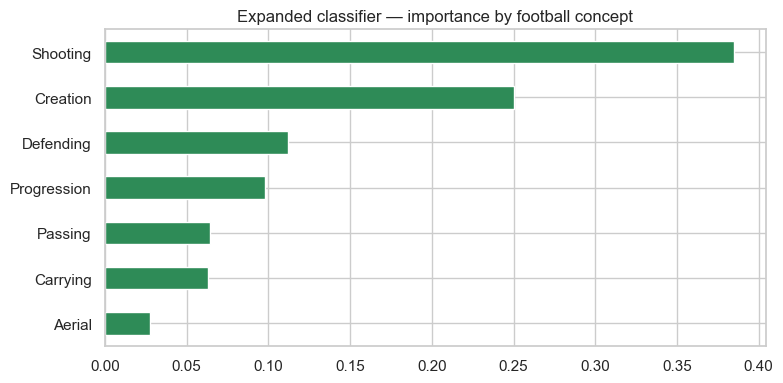

Aerial         0.027
Carrying       0.063
Passing        0.064
Progression    0.098
Defending      0.112
Creation       0.250
Shooting       0.385
dtype: float64

In [9]:
rf_exp = RandomForestClassifier(n_estimators=400, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1).fit(df[EXPANDED_B], y)
imp = pd.Series(rf_exp.feature_importances_, index=EXPANDED_B)
grouped_importance = pd.Series({g: imp[[f for f in feats if f in imp.index]].sum() for g, feats in GROUPS.items()}).sort_values()
plt.figure(figsize=(8, 4)); grouped_importance.plot.barh(color="seagreen")
plt.title("Expanded classifier — importance by football concept"); plt.tight_layout(); plt.show()
grouped_importance.round(3)

## 9. Role-aware clustering (data-driven K)
K-Means on the **percentile-ranked profiling features** (robust, comparable scales). Position is **not**
an input — it is used only to validate the groups afterwards. We pick K from silhouette + inertia +
minimum cluster size + interpretability, then name each cluster from its measured category indices and
position mix (a name is only used when the statistics support it).

In [10]:
sim_scaler = StandardScaler().fit(pct_overall.values)          # percentile-space, standardised
Z = sim_scaler.transform(pct_overall.values)
ks = range(2, 9); diag = []
for k in ks:
    km = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    sizes = np.bincount(km.labels_)
    diag.append({"K": k, "Silhouette": silhouette_score(Z, km.labels_), "Inertia": km.inertia_,
                 "Min cluster %": 100 * sizes.min() / len(Z)})
rich_k_table = pd.DataFrame(diag).round({"Silhouette": 3, "Inertia": 1, "Min cluster %": 1})
display(rich_k_table)
# choose: best silhouette among K>=4 with min cluster >= 5% (more specific than the 3-role baseline)
cand = rich_k_table[(rich_k_table.K >= 4) & (rich_k_table["Min cluster %"] >= 5)]
RICH_K = int(cand.loc[cand.Silhouette.idxmax(), "K"]) if not cand.empty else 4
kmeans = KMeans(RICH_K, n_init=10, random_state=RANDOM_STATE).fit(Z)
df["Cluster"] = kmeans.labels_
print("Chosen K =", RICH_K, "| silhouette =", round(silhouette_score(Z, kmeans.labels_), 3))

,K,Silhouette,Inertia,Min cluster %
0,2,0.285,35443.6,44.3
1,3,0.206,30553.6,32.2
2,4,0.175,27598.6,15.8
3,5,0.174,25598.7,15.1
4,6,0.152,24334.9,13.5
5,7,0.133,23424.1,10.5
6,8,0.136,22670.0,10.4


Chosen K = 4 | silhouette = 0.175


In [11]:
# name each cluster from its mean category indices + dominant position (data-derived, defensible)
cat_cols = list(cat_df.columns)
prof_means = df.groupby("Cluster")[cat_cols].mean()
posmix = pd.crosstab(df.Cluster, df.Position, normalize="index") * 100
ROLE = {"Shooting": "Finisher", "Creation": "Creator", "Passing": "Playmaker",
        "Progression": "Progressor", "Carrying": "Dribbler", "Defending": "Defensive", "Aerial": "Aerial"}
def name_cluster(c):
    top = prof_means.loc[c].idxmax().replace("idx_", "")
    pos = posmix.loc[c].idxmax()
    base = ROLE[top]
    if pos == "Defender":
        base = {"Passing": "Ball-playing defender", "Aerial": "Aerial defender",
                "Defending": "Defensive defender"}.get(top, base + " defender")
    elif pos == "Midfielder":
        base = base + " midfielder"
    return base   # forwards keep the bare role (Finisher / Progressor / Creator / Dribbler)
names, seen = {}, {}
for c in prof_means.index:
    nm = name_cluster(c); seen[nm] = seen.get(nm, 0) + 1
    names[c] = nm if seen[nm] == 1 else f"{nm} {seen[nm]}"
df["Profile"] = df.Cluster.map(names)
rich_cluster_names = names
rich_cluster_profile = prof_means.round(1)
rich_cluster_profile["Players"] = df.Cluster.value_counts().sort_index()
print("Role-aware profiles:");
for c in prof_means.index:
    print(f"  cluster {c}: {names[c]:28s} top={prof_means.loc[c].idxmax().replace('idx_','')} "
          f"| {posmix.loc[c].idxmax()} {posmix.loc[c].max():.0f}%")
display(rich_cluster_profile.rename(index=names))

Role-aware profiles:
  cluster 0: Finisher                     top=Shooting | Forward 86%
  cluster 1: Defensive defender           top=Defending | Defender 51%
  cluster 2: Progressor                   top=Progression | Forward 48%
  cluster 3: Aerial defender              top=Aerial | Defender 83%


,idx_Shooting,idx_Creation,idx_Passing,idx_Progression,idx_Carrying,idx_Defending,idx_Aerial,Players
Cluster,,,,,,,,
Finisher,83.7,58.9,21.8,56.4,29.1,23.2,52.5,288
Defensive defender,37.9,52.2,59.5,52.6,56.6,61.4,45.4,609
Progressor,74.7,79.0,43.7,81.2,54.7,33.5,26.8,406
Aerial defender,26.4,20.1,59.4,19.3,50.3,64.5,72.1,523


## 10. Player map (PCA on profiling space)

variance explained: [42.3 18.1]


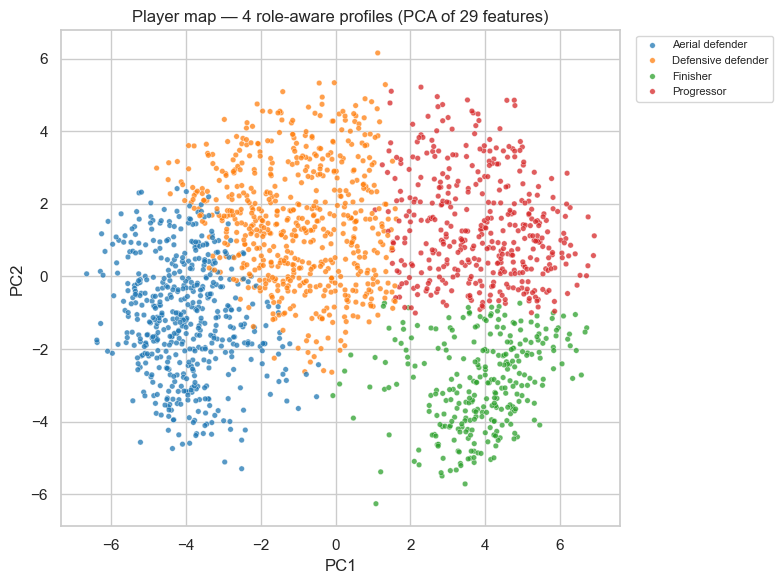

In [12]:
pca = PCA(2, random_state=RANDOM_STATE).fit(Z)
pcs = pca.transform(Z); df["PC1"], df["PC2"] = pcs[:, 0], pcs[:, 1]
print("variance explained:", (100 * pca.explained_variance_ratio_).round(1))
plt.figure(figsize=(8, 6)); sns.scatterplot(x=df.PC1, y=df.PC2, hue=df.Profile, s=16, alpha=.75, palette="tab10")
plt.title(f"Player map — {RICH_K} role-aware profiles (PCA of {len(PROFILING)} features)")
plt.legend(bbox_to_anchor=(1.02, 1), fontsize=8); plt.tight_layout(); plt.show()

## 11. Richer similarity (style space) — cosine vs euclidean, with sanity checks
Similarity uses the standardised percentile space. We compare Euclidean distance and cosine similarity on
example players, offer a same-position mode, and keep Euclidean as the default (consistent with the app).
Examples are **validation only** — the system is never tuned to produce a specific match.

In [13]:
from numpy.linalg import norm
def euclid_sim(i, same_pos=False, n=5):
    d = norm(Z - Z[i], axis=1)
    order = [j for j in np.argsort(d) if j != i]
    if same_pos: order = [j for j in order if df.Position.iloc[j] == df.Position.iloc[i]]
    order = order[:n]
    return [(df.Player.iloc[j], df.Position.iloc[j], round(100 * (1 - d[j] / d.max()), 1)) for j in order]
def cosine_sim(i, n=5):
    cs = (Z @ Z[i]) / (norm(Z, axis=1) * norm(Z[i]) + 1e-9)
    order = [j for j in np.argsort(-cs) if j != i][:n]
    return [(df.Player.iloc[j], round(100 * cs[j], 1)) for j in order]
for name in ["Bukayo Saka", "Rodri", "Jude Bellingham", "Erling Haaland", "Virgil van Dijk"]:
    hit = df.index[df.Player == name]
    if len(hit) == 0: continue
    i = int(hit[0])
    print(f"\n{name} ({df.Position.iloc[i]}) — euclidean:", euclid_sim(i))
    print(f"{'':>{len(name)}}   same-position:", euclid_sim(i, same_pos=True))
    print(f"{'':>{len(name)}}   cosine       :", cosine_sim(i))


Bukayo Saka (Forward) — euclidean: [('Bradley Barcola', 'Forward', np.float64(81.7)), ('Gabriel Martinelli', 'Forward', np.float64(81.6)), ('Rodrigo Riquelme', 'Defender', np.float64(81.6)), ('Eberechi Eze', 'Midfielder', np.float64(81.5)), ('Nathan Tella', 'Defender', np.float64(80.9))]
              same-position: [('Bradley Barcola', 'Forward', np.float64(81.7)), ('Gabriel Martinelli', 'Forward', np.float64(81.6)), ('Marcus Tavernier', 'Forward', np.float64(79.2)), ('Lamine Yamal', 'Forward', np.float64(78.7)), ('Antony', 'Forward', np.float64(78.1))]
              cosine       : [('Bradley Barcola', np.float64(92.2)), ('Gabriel Martinelli', np.float64(92.2)), ('Eberechi Eze', np.float64(91.9)), ('Rodrigo Riquelme', np.float64(91.9)), ('Nathan Tella', np.float64(91.6))]

Rodri (Forward) — euclidean: [('Matìas Soulé', 'Forward', np.float64(80.7)), ('Julien Ponceau', 'Midfielder', np.float64(80.3)), ('Lee Kang-in', 'Forward', np.float64(80.1)), ('Luis Henrique', 'Forward', np.float64

## 12. Sanity checks

In [14]:
assert not ({"Goals_p90", "Assists_p90", "NpGoals_p90", "Score", "Label"} & set(EXPANDED_B))
assert np.isfinite(Z).all() and -1 <= silhouette_score(Z, kmeans.labels_) <= 1
assert ((df[cat_cols] >= 0) & (df[cat_cols] <= 100)).all().all()
assert abs(y.mean() - 0.5) < 0.02
print("All sanity checks passed. players:", len(df), "| profiling features:", len(PROFILING), "| rich K:", RICH_K)

All sanity checks passed. players: 1826 | profiling features: 29 | rich K: 4


## 13. Save artifacts
Baseline keys are preserved; expanded keys are added. The app loads these and never retrains.

In [15]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump({
    # ---- baseline (unchanged) ----
    "features": BASELINE, "threshold": float(THRESHOLD), "season": SEASON,
    "reg_models": reg_models, "clf_models": clf_models,
    "reg_results": reg_results, "clf_results": clf_results, "cv_results": cv_results,
    "importances": importances,
    "test_preds": {"reg": reg_pred, "clf": clf_pred, "y_reg": yr_te.values, "y_clf": yc_te.values},
    # ---- expanded ----
    "groups": GROUPS, "profiling_features": PROFILING, "similarity_features": SIMILARITY,
    "category_cols": cat_cols,
    "expanded_clf": expanded_clf, "grouped_importance": grouped_importance,
    "sim_scaler": sim_scaler, "sim_space": Z.astype("float32"),
    "rich_k": RICH_K, "rich_cluster_names": rich_cluster_names, "rich_cluster_profile": rich_cluster_profile,
    "rich_k_table": rich_k_table, "pca_var": pca.explained_variance_ratio_,
}, "models/artifacts.joblib")

# predictions for display (baseline models) + rich profile + indices + map coords
df["Pred_Score"] = reg_models["Random Forest"].predict(df[BASELINE]).round(3)
df["Pred_Category"] = np.where(clf_models["Logistic Regression"].predict(df[BASELINE]) == 1, "High", "Low")
keep = (ID_COLS + ["Position"] + PROFILING + ["Goals_p90", "Assists_p90", "Score", "Label",
        "Pred_Score", "Pred_Category", "Cluster", "Profile", "PC1", "PC2"] + cat_cols)
keep = list(dict.fromkeys(keep))
df[keep].to_csv("models/players_scored.csv", index=False)
print("saved:", sorted(os.listdir("models")))
print("players_scored columns:", len(keep))

saved: ['artifacts.joblib', 'players_scored.csv']
players_scored columns: 54
